# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data_short.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
166,21,7,"(0.27, 1.1)","(0.126, 0.599, -0.03, -0.34)",1,1.0,"(0.138, 0.788, -0.037, -0.497)",1.0,1.0,"(0.154, 0.977, -0.047, -0.654)"
181,5,8,"(0.63, 0.6)","(0.02, 0.252, -0.081, -0.443)",1,1.0,"(0.025, 0.453, -0.09, -0.872)",1.0,1.0,"(0.034, 0.655, -0.107, -1.305)"
142,4,6,"(0.97, 0.2)","(0.003, -0.003, -0.02, -0.304)",1,1.0,"(0.003, 0.273, -0.026, -2.358)",1.0,1.0,"(0.008, 0.548, -0.073, -4.423)"
42,12,3,"(0.05, 1.7)","(-0.07, 0.714, 0.047, -0.277)",0,1.0,"(-0.056, 0.528, 0.041, -0.19)",1.0,1.0,"(-0.045, 0.714, 0.037, -0.269)"
46,16,3,"(0.05, 1.7)","(-0.013, 0.713, 0.025, -0.263)",1,1.0,"(0.001, 0.899, 0.02, -0.344)",1.0,1.0,"(0.019, 1.084, 0.013, -0.425)"
...,...,...,...,...,...,...,...,...,...,...
195,8,9,"(0.11, 0.5)","(0.034, -0.023, 0.017, 0.06)",0,1.0,"(0.033, -0.218, 0.018, 0.36)",0.0,1.0,"(0.029, -0.414, 0.025, 0.66)"
83,10,4,"(0.93, 1.7)","(-0.06, -1.156, 0.17, 1.443)",0,1.0,"(-0.083, -1.349, 0.199, 1.687)",1.0,1.0,"(-0.11, -1.159, 0.233, 1.528)"
49,19,3,"(0.05, 1.7)","(0.041, 1.27, 0.004, -0.507)",0,1.0,"(0.066, 1.084, -0.006, -0.424)",1.0,1.0,"(0.088, 1.27, -0.014, -0.507)"
8,8,0,"(0.24, 0.6)","(-0.027, -0.352, 0.006, 0.57)",0,1.0,"(-0.034, -0.546, 0.018, 0.843)",0.0,1.0,"(-0.045, -0.741, 0.034, 1.12)"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.0851287990808487, 1.598985195159912]","[0.09404665976762772, 1.4532965421676636]","[0.0357464924454689, 0.43358325958251953, 0.03...",1.825235,1.799321,0.430128
1,1,"[0.08495253324508667, 1.5966094732284546]","[0.09384150803089142, 1.451486349105835]","[0.03488413617014885, 0.4302743673324585, 0.02...",1.825075,1.785746,0.425344
2,2,"[0.0847974494099617, 1.594087839126587]","[0.09364631026983261, 1.4495036602020264]","[0.03404589742422104, 0.4269002377986908, 0.02...",1.824928,1.772352,0.420500
3,3,"[0.08466605842113495, 1.5931364297866821]","[0.09346288442611694, 1.4489959478378296]","[0.033233121037483215, 0.4235818088054657, 0.0...",1.824797,1.759132,0.415800
4,4,"[0.08455239236354828, 1.5931564569473267]","[0.0932922288775444, 1.4494109153747559]","[0.03244409337639809, 0.4203067421913147, 0.02...",1.824681,1.746079,0.411215


In [4]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
166,21,7,"(0.27, 1.1)","(0.126, 0.599, -0.03, -0.34)",1,1.0,"(0.138, 0.788, -0.037, -0.497)",1.0,1.0,"(0.154, 0.977, -0.047, -0.654)"
181,5,8,"(0.63, 0.6)","(0.02, 0.252, -0.081, -0.443)",1,1.0,"(0.025, 0.453, -0.09, -0.872)",1.0,1.0,"(0.034, 0.655, -0.107, -1.305)"
142,4,6,"(0.97, 0.2)","(0.003, -0.003, -0.02, -0.304)",1,1.0,"(0.003, 0.273, -0.026, -2.358)",1.0,1.0,"(0.008, 0.548, -0.073, -4.423)"
42,12,3,"(0.05, 1.7)","(-0.07, 0.714, 0.047, -0.277)",0,1.0,"(-0.056, 0.528, 0.041, -0.19)",1.0,1.0,"(-0.045, 0.714, 0.037, -0.269)"
46,16,3,"(0.05, 1.7)","(-0.013, 0.713, 0.025, -0.263)",1,1.0,"(0.001, 0.899, 0.02, -0.344)",1.0,1.0,"(0.019, 1.084, 0.013, -0.425)"


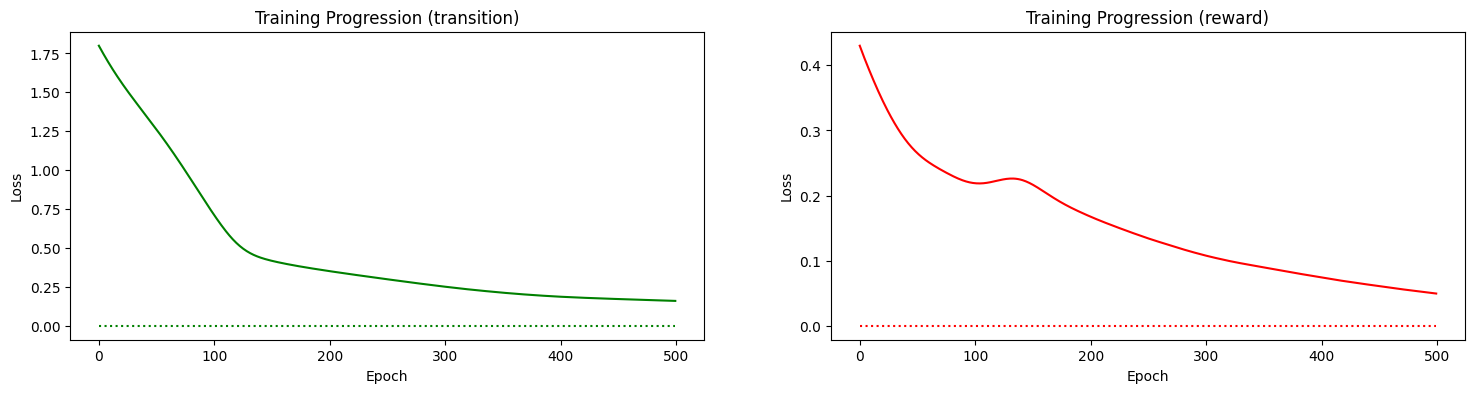

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

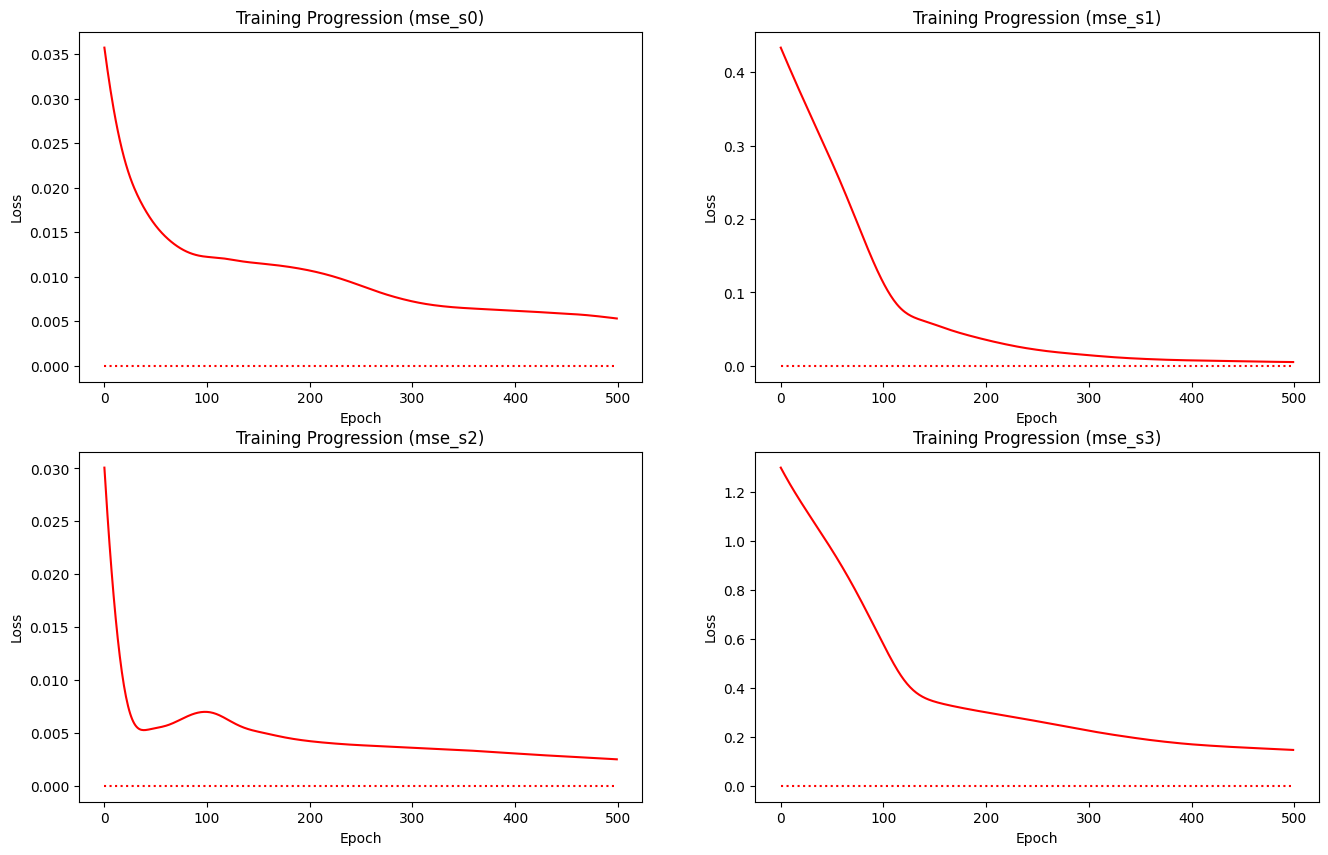

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

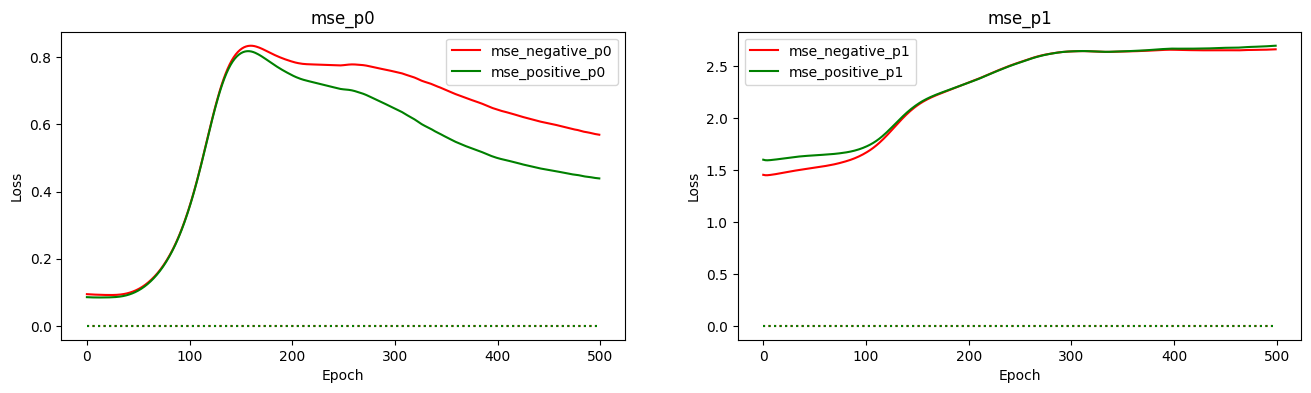

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [8]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data, expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_7728/2347339348.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,0,0.27,1.1,0.63,1.5,0.413761,0.014674,0.0
1,0,0.63,0.6,0.05,1.7,0.433423,0.014146,1.0
2,0,0.97,0.2,0.63,0.6,0.457243,-0.051730,2.0
3,0,0.05,1.7,0.93,1.7,0.352169,-0.002432,3.0
4,0,0.05,1.7,0.63,0.6,0.407946,0.014091,4.0


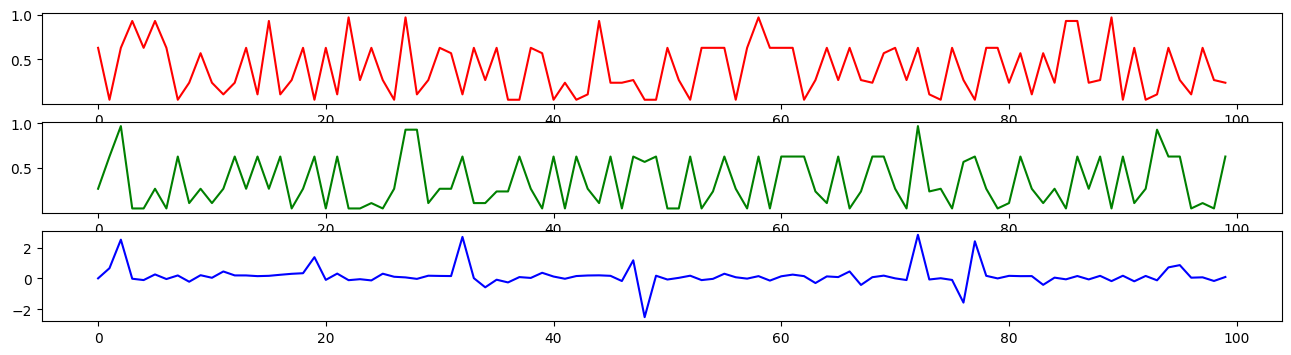

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

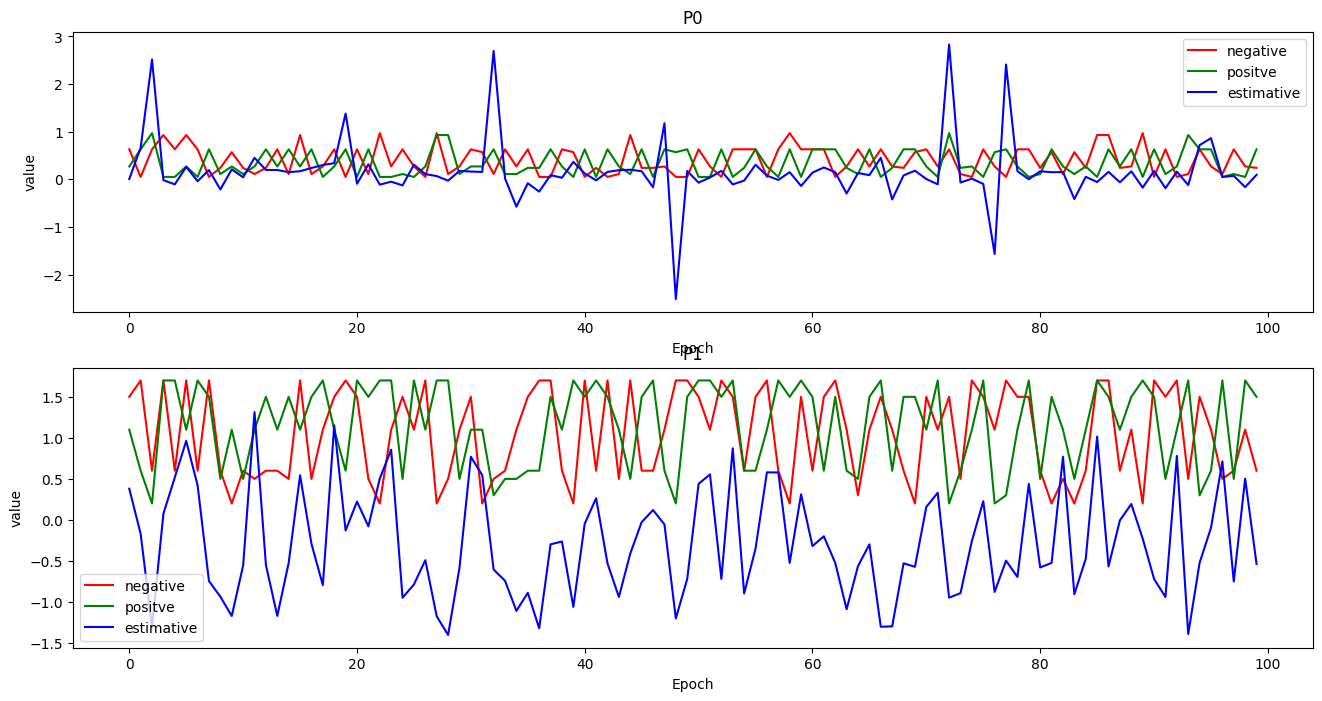

In [10]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [11]:
data.evaluate_model(model, path='training_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.24, 0.6)","(-0.041, 0.037, 0.015, -0.0)",0,1.0,"(-0.04, -0.157, 0.015, 0.276)",1.0,1.0,"(-0.043, 0.037, 0.02, 0.009)",...,0.030,0.24,0.6,0.038,-0.682,0.054,0.020,0.020,0.021,0.2
1,1,0,"(0.24, 0.6)","(-0.04, -0.157, 0.015, 0.276)",1,1.0,"(-0.043, 0.037, 0.02, 0.009)",1.0,1.0,"(-0.042, 0.231, 0.02, -0.257)",...,-0.289,0.24,0.6,0.181,-0.521,0.058,0.025,0.012,0.032,0.2
2,2,0,"(0.24, 0.6)","(-0.043, 0.037, 0.02, 0.009)",1,1.0,"(-0.042, 0.231, 0.02, -0.257)",1.0,1.0,"(-0.038, 0.425, 0.015, -0.523)",...,-0.497,0.24,0.6,0.197,-0.319,0.062,0.008,0.036,0.026,0.2
3,3,0,"(0.24, 0.6)","(-0.042, 0.231, 0.02, -0.257)",1,1.0,"(-0.038, 0.425, 0.015, -0.523)",0.0,1.0,"(-0.029, 0.23, 0.005, -0.247)",...,-0.244,0.24,0.6,0.243,-0.069,0.080,0.034,0.033,0.003,0.2
4,4,0,"(0.24, 0.6)","(-0.038, 0.425, 0.015, -0.523)",0,1.0,"(-0.029, 0.23, 0.005, -0.247)",0.0,1.0,"(-0.025, 0.036, -0.0, 0.026)",...,0.089,0.24,0.6,0.096,-0.217,0.062,0.024,0.001,0.063,0.2


In [12]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([9, 0, 7]) worst_episodes=array([1, 2, 6])


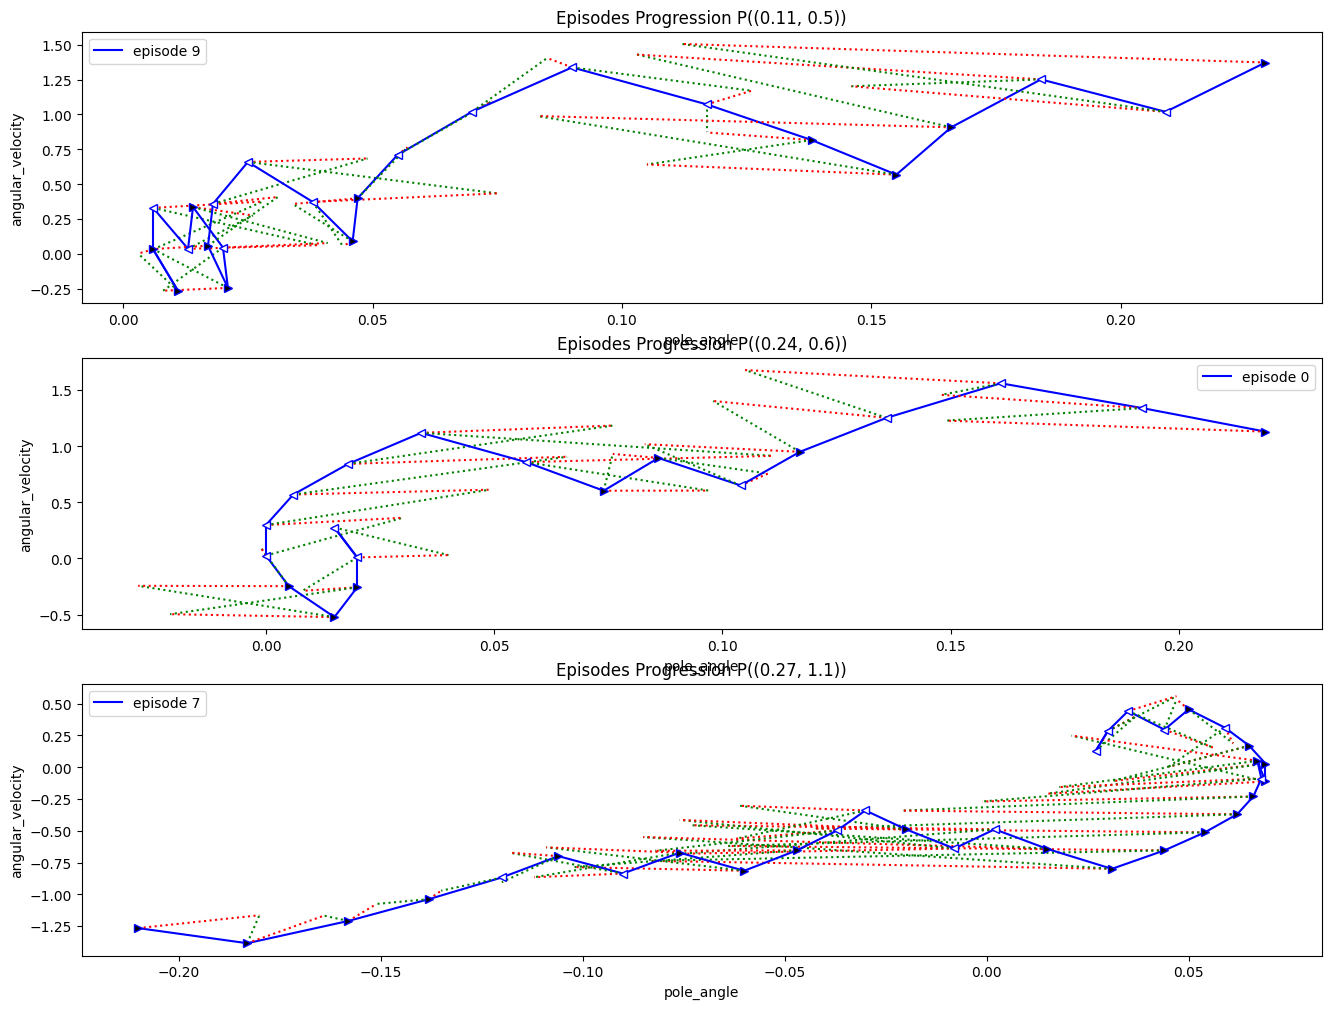

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

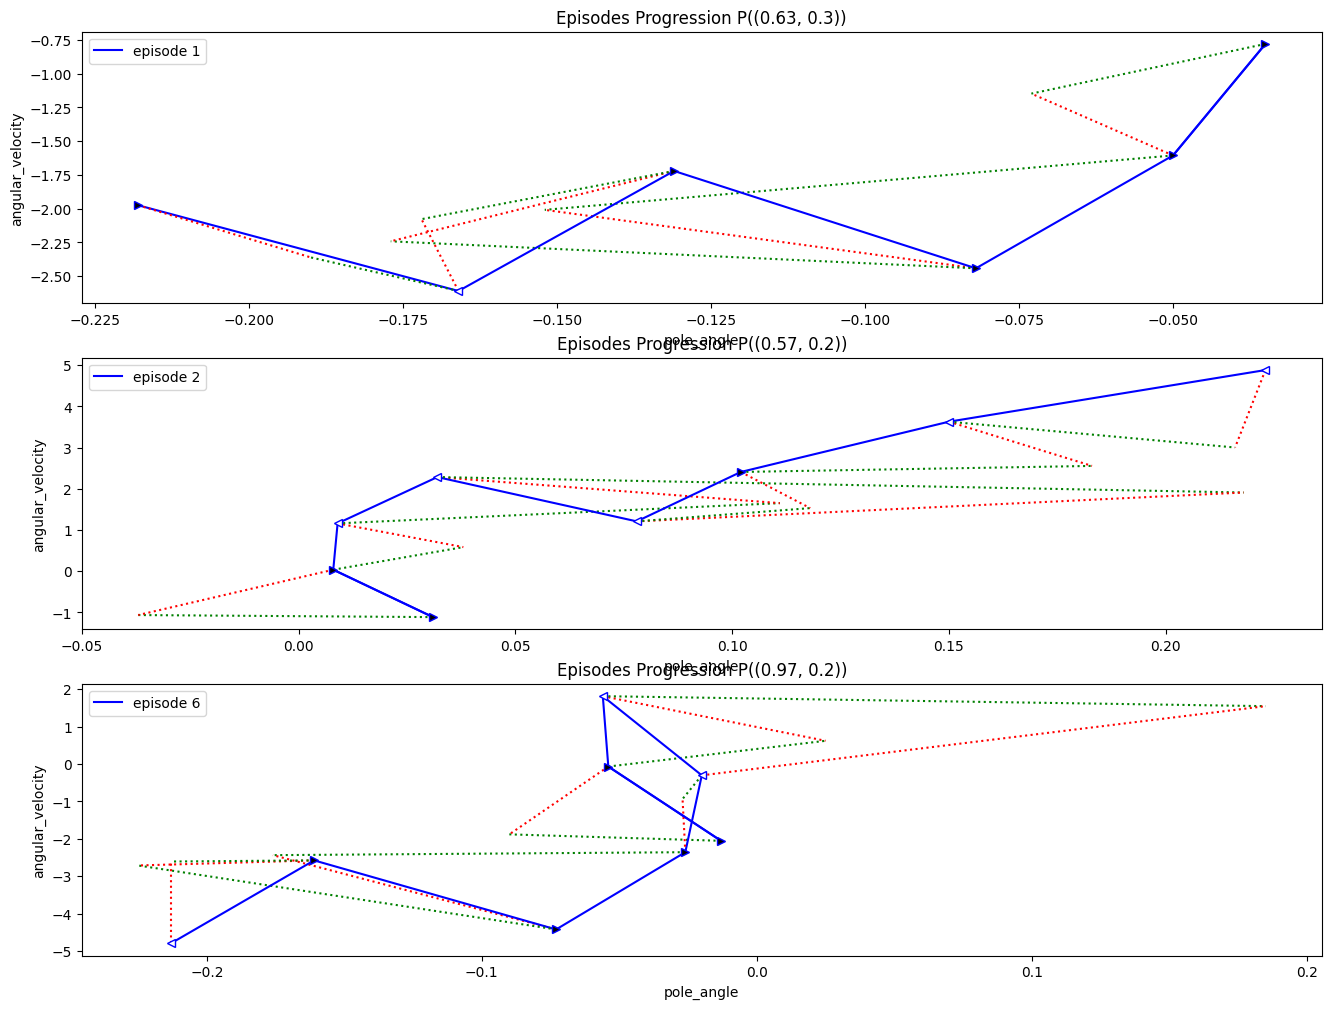

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

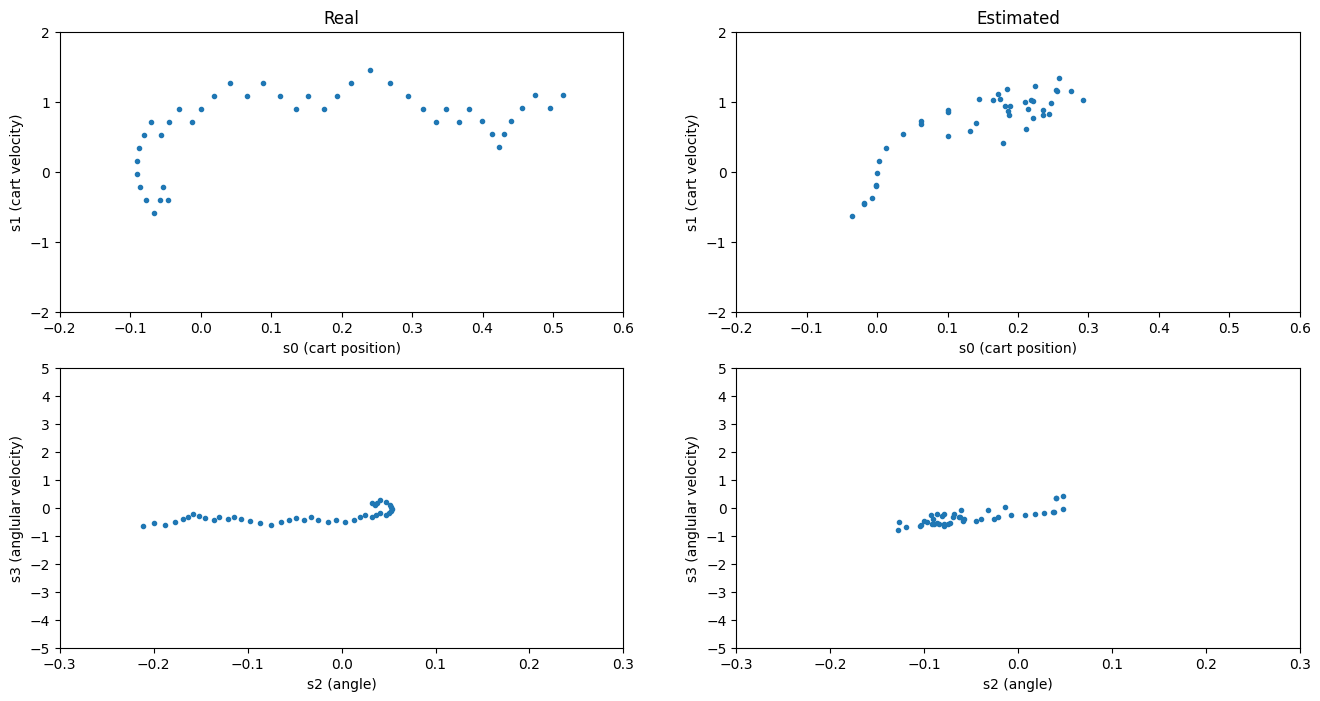

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

df = results.loc[results.episode == 3]

axs[0][0].scatter(x=df['s0'], y=df['s1'], marker='.')
axs[1][0].scatter(x=df['s2'], y=df['s3'], marker='.')

axs[0][1].scatter(x=df['estimated_s0'], y=df['estimated_s1'], marker='.')
axs[1][1].scatter(x=df['estimated_s2'], y=df['estimated_s3'], marker='.')

axs[0][0].set_title('Real')
axs[0][1].set_title('Estimated')

for i, _ in enumerate(axs[0]):
    axs[0][i].set_ylabel('s1 (cart velocity)')
    axs[0][i].set_xlabel('s0 (cart position)')
    axs[0][i].set_yticks(range(-2,3))
    axs[0][i].set_xticks([i/10 for i in range(-2,7)])

for i, _ in enumerate(axs[0]):
    axs[1][i].set_ylabel('s3 (anglular velocity)')
    axs[1][i].set_xlabel('s2 (angle)')
    axs[1][i].set_yticks(range(-5,6))
    axs[1][i].set_xticks([i/10 for i in range(-3,4)])

plt.show()

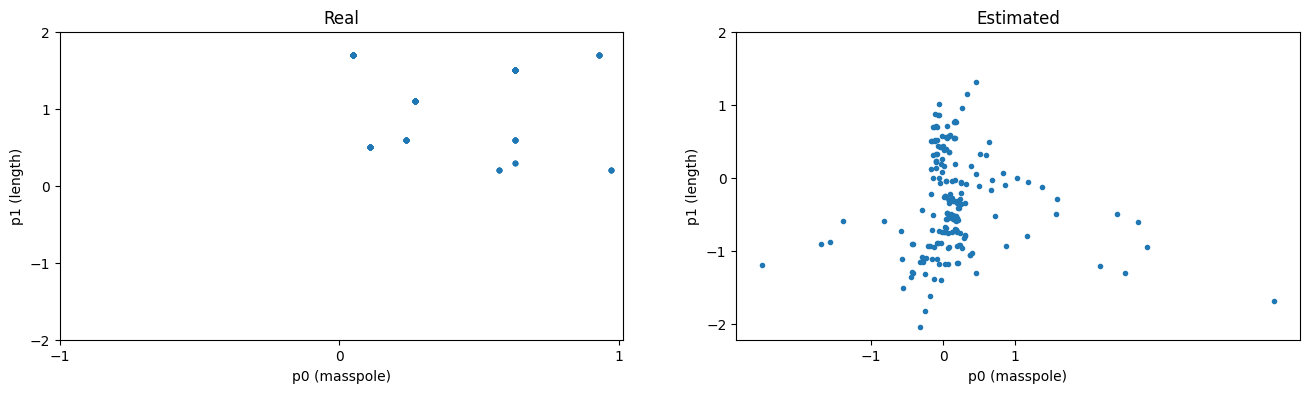

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

# df = results.loc[results.episode == 3]
df = results

axs[0].scatter(x=df['p0'], y=df['p1'], marker='.')
axs[1].scatter(x=df['estimated_p0'], y=df['estimated_p1'], marker='.')

axs[0].set_title('Real')
axs[1].set_title('Estimated')

for ax in axs:
    ax.set_ylabel('p1 (length)')
    ax.set_xlabel('p0 (masspole)')
    ax.set_yticks(range(-2,3))
    ax.set_xticks(range(-1,2))

plt.show()

In [17]:
from sklearn.cluster import KMeans
import numpy as np
X = df[['p0', 'p1']]
kmeans = KMeans(n_clusters=5, random_state=50, n_init="auto").fit(X)
kmeans.labels_
# kmeans.predict([[0, 0], [12, 3]])
# kmeans.cluster_centers_

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

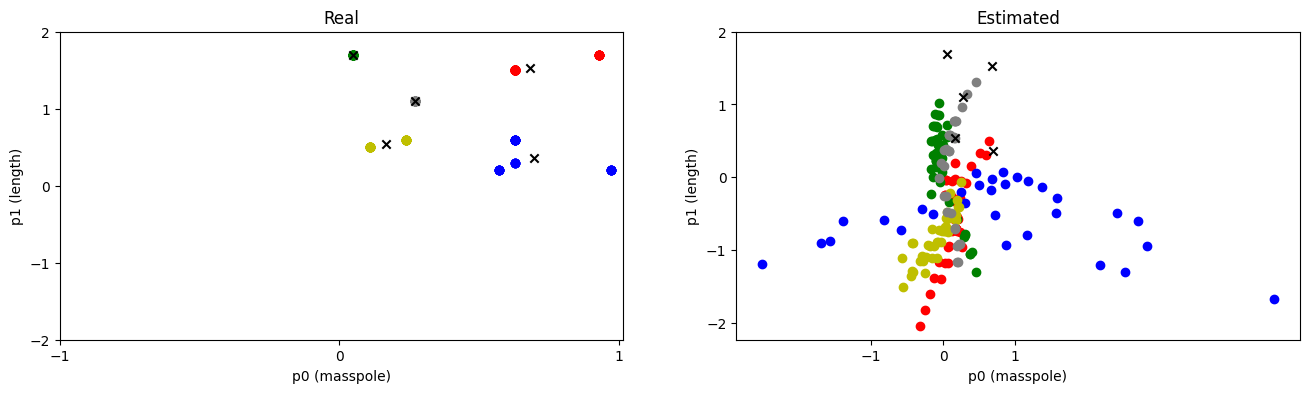

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

colors = ['r', 'b', 'g', 'y', 'gray']

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = X[kmeans.labels_ == label]
    axs[0].scatter(cluster_points['p0'], cluster_points['p1'], color=colors[i])
axs[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = df[kmeans.labels_ == label]
    axs[1].scatter(cluster_points['estimated_p0'], cluster_points['estimated_p1'], color=colors[i])
axs[1].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')


axs[0].set_title('Real')
axs[1].set_title('Estimated')

for ax in axs:
    ax.set_ylabel('p1 (length)')
    ax.set_xlabel('p0 (masspole)')
    ax.set_yticks(range(-2,3))
    ax.set_xticks(range(-1,2))

plt.show()

# Evaluation

In [19]:
data.evaluate_model(model, path='testing_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.27, 1.9)","(-0.037, 0.026, -0.021, 0.016)",0,1.0,"(-0.036, -0.159, -0.02, 0.102)",0.0,1.0,"(-0.04, -0.345, -0.018, 0.188)",...,0.325,0.27,1.9,0.255,-0.746,0.034,0.069,0.053,0.137,0.3
1,1,0,"(0.27, 1.9)","(-0.036, -0.159, -0.02, 0.102)",0,1.0,"(-0.04, -0.345, -0.018, 0.188)",0.0,1.0,"(-0.047, -0.531, -0.014, 0.274)",...,0.395,0.27,1.9,0.340,-0.987,0.026,0.054,0.056,0.121,0.3
2,2,0,"(0.27, 1.9)","(-0.04, -0.345, -0.018, 0.188)",0,1.0,"(-0.047, -0.531, -0.014, 0.274)",1.0,1.0,"(-0.057, -0.345, -0.009, 0.185)",...,-0.088,0.27,1.9,0.426,-1.230,0.061,0.019,0.050,0.273,0.3
3,3,0,"(0.27, 1.9)","(-0.047, -0.531, -0.014, 0.274)",1,1.0,"(-0.057, -0.345, -0.009, 0.185)",0.0,1.0,"(-0.064, -0.531, -0.005, 0.272)",...,0.374,0.27,1.9,0.369,-0.964,0.043,0.042,0.046,0.102,0.3
4,4,0,"(0.27, 1.9)","(-0.057, -0.345, -0.009, 0.185)",0,1.0,"(-0.064, -0.531, -0.005, 0.272)",1.0,1.0,"(-0.075, -0.345, 0.0, 0.183)",...,-0.080,0.27,1.9,0.428,-1.232,0.076,0.014,0.043,0.263,0.3


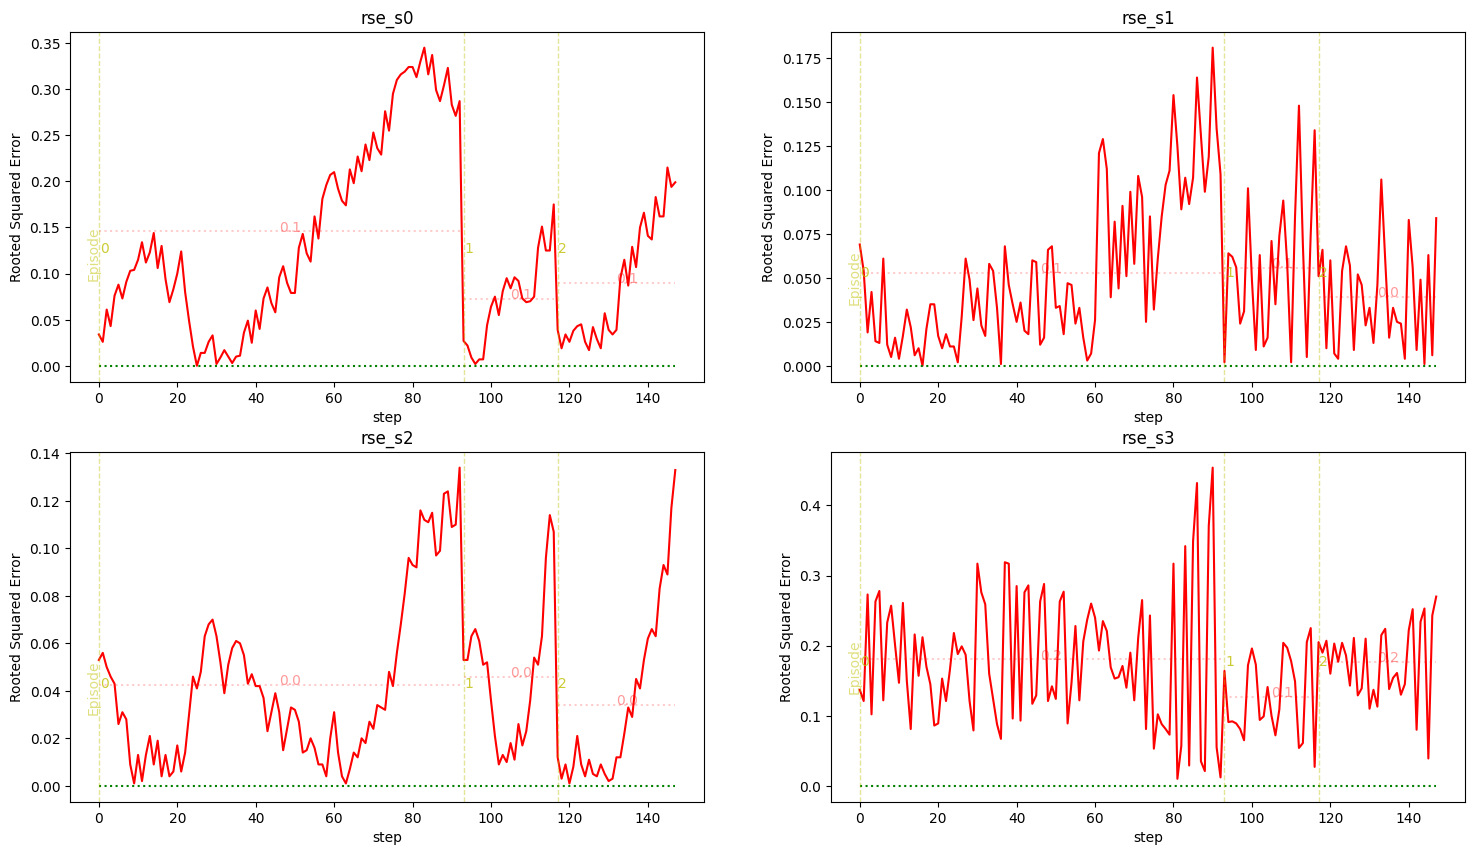

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

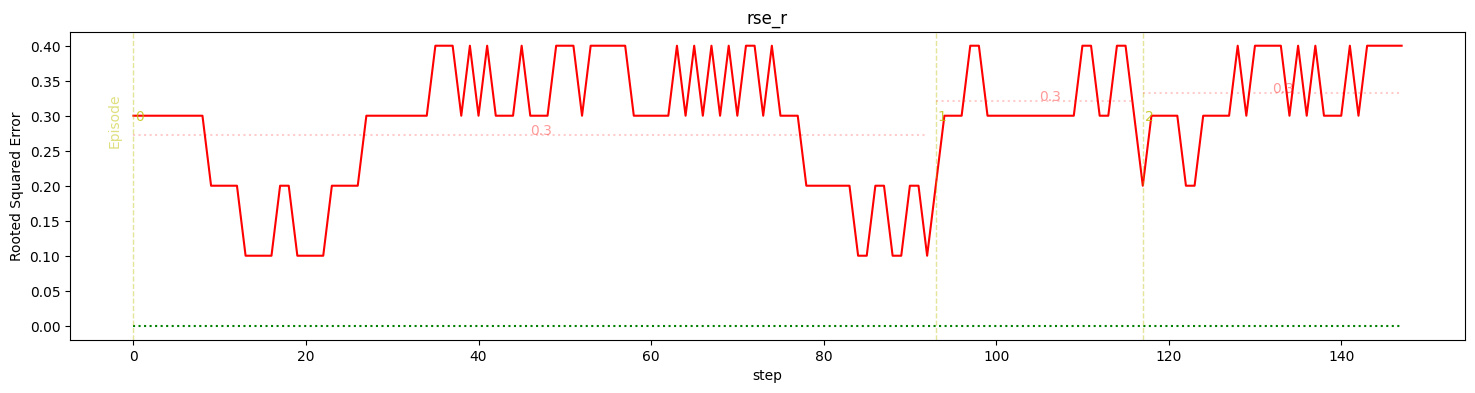

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

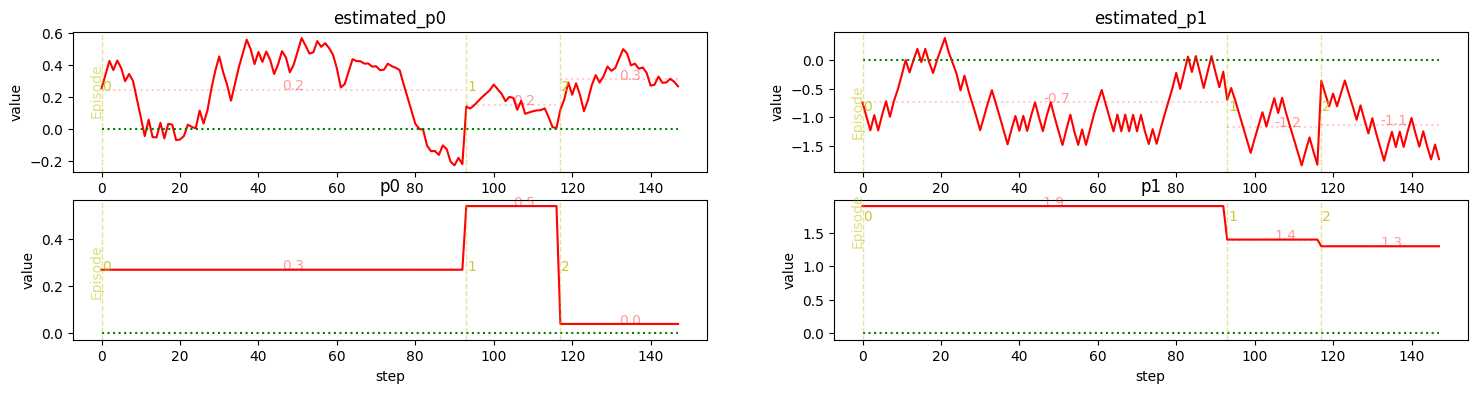

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], results, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], results, 'estimated_p1', y_label='value')
data.plot_value_through_episodes(axs[1][0], results, 'p0', y_label='value')
data.plot_value_through_episodes(axs[1][1], results, 'p1', y_label='value')
plt.show()

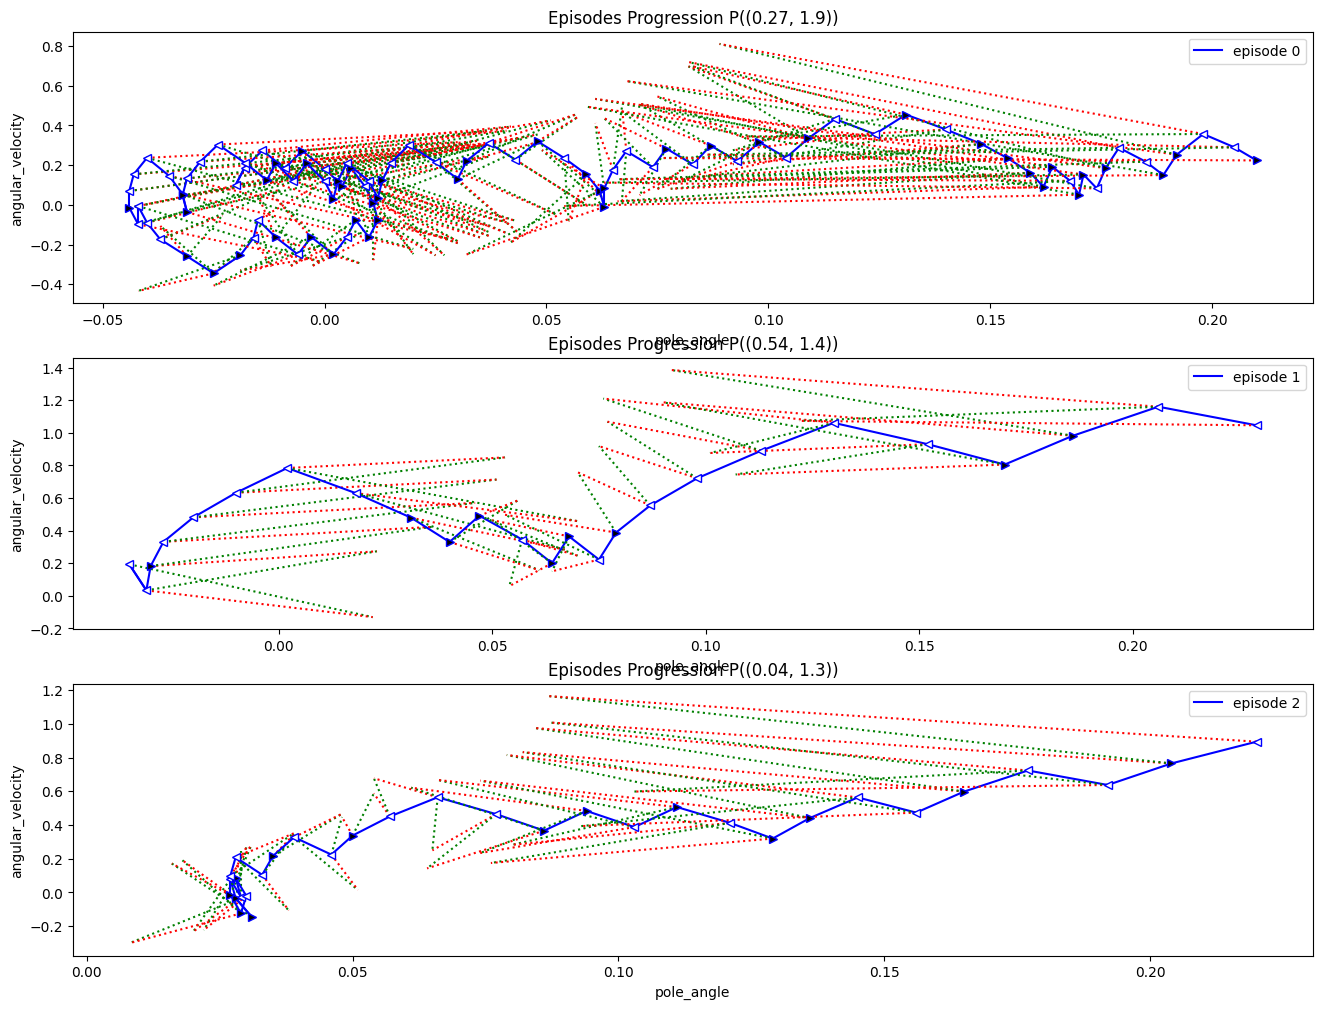

In [23]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()